# 3D acoustic full-waveform inversion (FWI) example — `model_0000`

This notebook walks through a minimal **3D acoustic FWI** workflow using [Deepwave](https://github.com/ar4/deepwave).


**Full waveform inversion** updates an Earth model (here, P-wave velocity $v_p$) so that **synthetic seismograms** from a wave-equation simulator match **observed** (or synthetic benchmark) data. At each iteration:

1. **Forward model** — propagate waves through the current $v_p$ model.
2. **Misfit** — measure the difference between synthetic and observed data (here, mean-squared error on band-pass filtered traces).
3. **Adjoint / backprop** — Deepwave provides differentiable forward modeling, so gradients of the misfit with respect to $v_p$ are obtained via automatic differentiation.
4. **Update** — an optimizer (Adam) adjusts the model parameters and repeats.

This example uses **observed data generated from the true model** (a synthetic benchmark), which is common for method development before applying FWI to field data.

## Notebook workflow

| Step | Section |
|------|---------|
| 1 | Load true $v_p$ and define the simulation grid |
| 2 | Build a smooth **starting model** and parameterize $v_p$ for inversion |
| 3 | Define sources, receivers, and boundary conditions |
| 4 | Taper and band-pass filter traces (multiscale strategy) |
| 5 | Forward model **observed data** on $v_{\mathrm{true}}$ |
| 6 | **Invert** $v_p$ with multiscale Adam (low → high frequency) |

**Requirements:** PyTorch with CUDA (recommended), Deepwave, SciPy, torchaudio (for differentiable `biquad` filtering).

To run on other GeoFWI3D models, download the dataset from the [GeoFWI3D Box folder](https://utexas.box.com/s/ybzgil0u3hvgusoc27bechxibyck88jr) and point `data_root` to the extracted `allmodels/` directory (see the main repository README).


In [ ]:
import os, sys
sys.path.insert(0, os.path.expanduser("../quick_start"))

In [ ]:
import torch
import matplotlib.pyplot as plt
from scipy.signal import butter
from torchaudio.functional import biquad
import deepwave
from deepwave import scalar
from scipy.ndimage import gaussian_filter
import numpy as np
from plotting import plot3d

## Step 1 — Velocity model and simulation grid

Load the true P-wave velocity $v_p$ from `vp3d.bin` (`float32`, shape $96 \times 96 \times 96$ in file order $(x,y,z)$). The volume is reshaped to **$(n_z, n_y, n_x)$** for Deepwave (depth first).

**Grid:** spacing `dz`, `dy`, `dx` (m) sets the physical extent. **Time:** `nt` samples at interval `dt` (s) define recording length.

**Source wavelet:** a **Ricker** with peak frequency `freq` (Hz); `peak_time` delays the pulse so energy is not clipped at $t=0$.


In [ ]:
# Setup
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)

nz, ny, nx = 96, 96, 96

#download all models from https://utexas.box.com/s/ybzgil0u3hvgusoc27bechxibyck88jr
file = "allmodels/model_0000/vp3d.bin" 

v_true = np.fromfile(
    file,
    dtype=np.float32
).reshape(nx, ny, nz).T
v_true_tensor = torch.from_numpy(v_true).to(device)

dz, dy, dx = 10.0, 10.0, 10.0
nt, dt = 501, 0.002
freq = 25.0 # Max frequency for wavelet
peak_time = 1.5 / freq


cuda:1


## Step 2 — Starting model and $v_p$ parameterization

FWI needs a **starting model** $v_{\mathrm{init}}$ that is smooth and within plausible bounds. Here, $v_{\mathrm{init}}$ is a **Gaussian-smoothed** copy of $v_{\mathrm{true}}$ (`sigma=10`), which mimics a reasonable initial guess when the fine structure is unknown.

**Optimization variables:** raw velocities are not updated directly. A trainable **logit** is passed through **sigmoid** and mapped to $[v_{\min}, v_{\max}]$ (m/s), so every iterate stays physically bounded.

The plot below compares $v_{\mathrm{true}}$ and $v_{\mathrm{init}}$.


In [3]:
# Model & Constraints
class Model(torch.nn.Module):
    def __init__(self, initial, min_vel, max_vel):
        super().__init__()
        self.min_vel, self.max_vel = min_vel, max_vel
        
        # Normalize the initial velocity to the [0, 1] range
        normalized = (initial - min_vel) / (max_vel - min_vel)
        
        # Clamp the values to be strictly inside (0, 1) 
        safe_normalized = torch.clamp(normalized, min=1e-4, max=1.0 - 1e-4)
        
        # Apply logit safely
        self.model = torch.nn.Parameter(torch.logit(safe_normalized))

    def forward(self):
        return torch.sigmoid(self.model) * (self.max_vel - self.min_vel) + self.min_vel

# initial model
v_init = gaussian_filter(v_true, sigma=10, radius=10)
# v_init = np.linspace(1500, 3500, 96, dtype=np.float32).reshape(-1, 1, 1).repeat(96, axis=1).repeat(96, axis=2)
v_init_tensor = torch.from_numpy(v_init).to(device)

model = Model(v_init_tensor, 1200.0, 4000.0).to(device)

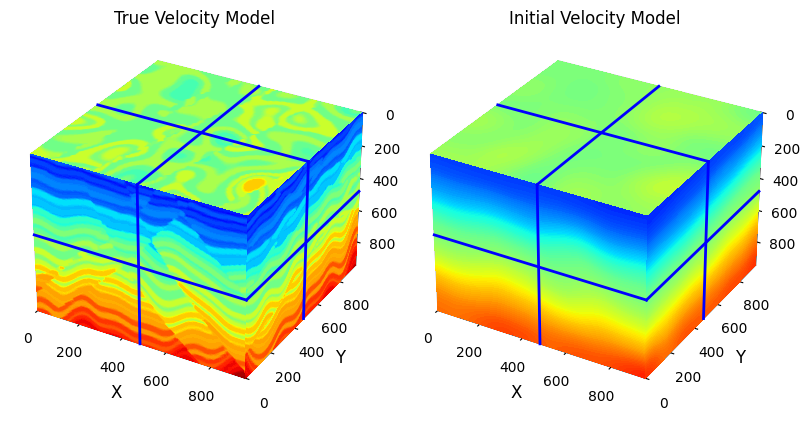

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), subplot_kw = {"projection": "3d"}, constrained_layout=True)
plt.sca(ax[0])
plot3d(
    v_true,
    cmap = "jet",
    vmin = 1500, vmax = 3500,
    ifnewfig=False,
    ifinside=False,
    showf=False,
    close=False,
    # nlevel=1000,
    dx=10.0, dy=10.0, dz=10.0
)

ax[0].set_title("True Velocity Model")

plt.sca(ax[1])
plot3d(
    # v_init,
    model().detach().cpu().numpy(),
    cmap = "jet",
    vmin = 1500, vmax = 3500,
    dx=10.0, dy=10.0, dz=10.0,
    ifnewfig=False,
    ifinside=False,
    showf=False,
    close=False,
)
ax[1].set_title("Initial Velocity Model")

plt.show()


## Step 3 — Acquisition geometry

Define where sources fire and where receivers record. This geometry is fixed during inversion.

- **Sources:** a $6 \times 6$ grid of shot positions in $(y,x)$ at shallow depth (`source_locations[..., 0] = 1`).
- **Receivers:** every surface grid point records each shot ($n_y \times n_x$ traces per shot).
- **Wavelet:** the same Ricker is used for all shots.
- **Boundaries:** absorbing **PML** on most faces; **`pml_width[0] = 0`** imposes a **free surface** on one side (typical for land/marine top).

Adjust `s_coords_y` / `s_coords_x` to change shot spacing or survey aperture.


In [9]:
s_coords_y = torch.linspace(5, ny-6, 6).long()
s_coords_x = torch.linspace(5, nx-6, 6).long()
n_shots = len(s_coords_y) * len(s_coords_x)
sy, sx = torch.meshgrid(s_coords_y, s_coords_x, indexing='ij')
source_locations = torch.zeros(n_shots, 1, 3, dtype=torch.long, device=device)
source_locations[:, 0, 0] = 1 
source_locations[:, 0, 1] = sy.flatten()
source_locations[:, 0, 2] = sx.flatten()

receiver_locations = torch.zeros(n_shots, ny * nx, 3, dtype=torch.long, device=device)
ry, rx = torch.meshgrid(torch.arange(ny).long(), torch.arange(nx).long(), indexing='ij')
receiver_locations[..., 0] = 1
receiver_locations[:, :, 1] = ry.flatten().to(device)
receiver_locations[:, :, 2] = rx.flatten().to(device)

source_amplitudes = deepwave.wavelets.ricker(freq, nt, dt, peak_time).repeat(n_shots, 1, 1).to(device)

pml_width = [0, 20, 20, 20, 20, 20] # free surface

## Step 4 — Tapering and band-pass filtering

Raw seismograms are processed before misfit evaluation:

- **`taper`** — cosine taper at the end of each trace to reduce edge effects from finite recording time.
- **`apply_filt`** — 4th-order **Butterworth** low-pass filter implemented as **biquad** stages on GPU tensors, so filtering remains inside the computational graph for backpropagation.

**Multiscale FWI:** inversion starts with a **low** cutoff frequency (easier, smoother updates) and progressively includes higher frequencies. This notebook uses cutoffs **10 → 15 → 25 Hz**.


In [6]:
def taper(x):
    return deepwave.common.cosine_taper_end(x, 50)

def get_filter(cutoff, dt, device):
    sos = butter(4, cutoff, fs=1/dt, output="sos")
    return [torch.from_numpy(s).to(device).to(torch.float32) for s in sos]

def apply_filt(x, sos_list):
    for s in sos_list:
        x = biquad(x, s[0], s[1], s[2], s[3], s[4], s[5])
    return x



## Step 5 — Synthetic observed data

Run the **forward** acoustic solver on $v_{\mathrm{true}}$ to create benchmark **observed** data. In field applications this step is replaced by loading real field records; here we know the answer and can check recovery.

`scalar(...)` returns receiver gathers stored on CPU to limit GPU memory use during the large forward pass.


In [8]:
with torch.no_grad():
    observed_data = scalar(
                        v_true_tensor, (dz, dy, dx), dt,      
                        source_amplitudes=source_amplitudes,
                        source_locations=source_locations, receiver_locations=receiver_locations,
                        pml_freq=freq, pml_width=pml_width,
    )[-1]
observed_data = taper(observed_data)

### Quality check — shot gathers

Inspect a subset of **observed** shot gathers (reshaped to $(n_{\mathrm{shots}}, n_y, n_x, n_t)$) before inversion. Look for moveout, amplitudes, and obvious artifacts; bad synthetics or acquisition bugs will show up here.


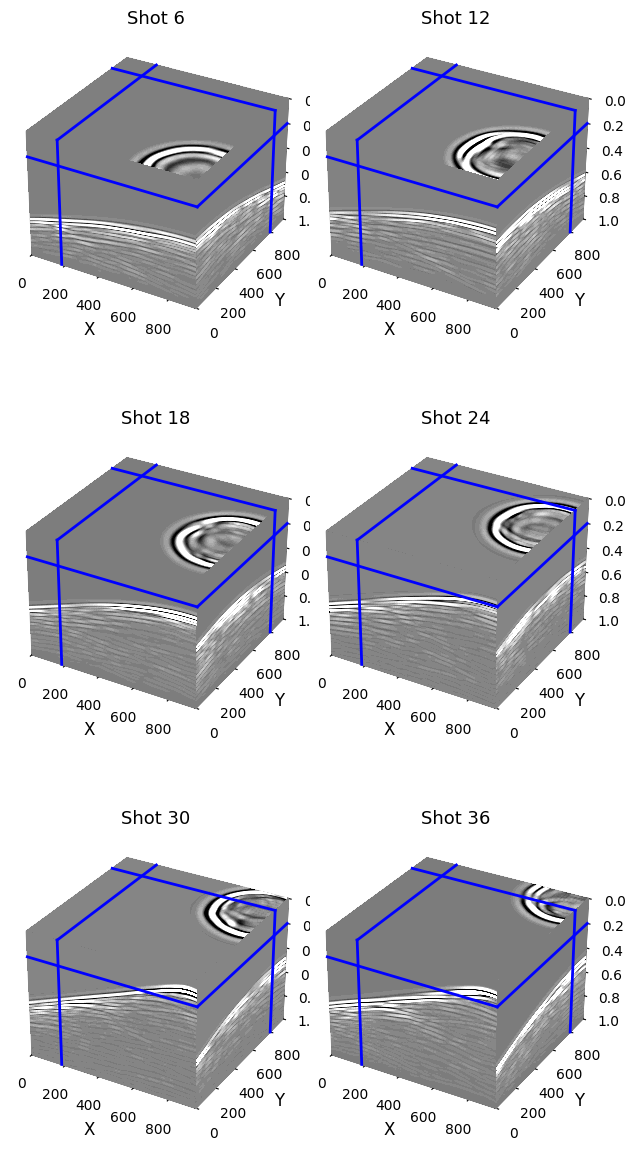

In [9]:
observed_data_3d = observed_data.reshape(n_shots, ny, nx, nt)
fig, axes = plt.subplots(3, 2, figsize=(6, 12), subplot_kw={"projection": "3d"}, constrained_layout=True)
axes = axes.ravel()

for i, ax in enumerate(axes):
    plt.sca(ax)
    plot3d(
        observed_data_3d[i*6+5].cpu().numpy().T,
        cmap="grey",
        vmin=-0.05, vmax=0.05,
        dx=10.0, dy=10.0, dz=0.002,
        frames=[100, 18, 80],
        ifinside=False,
        ifslice=True,
        showf=False,
        close=False,
        ifnewfig=False,
        nlevel=8000,
    )
    ax.set_title(f"Shot {i*6+6}", fontsize=13, pad=8)

plt.show()

### Memory management

Receiver data for all shots is large. Copy **`observed_data`** to NumPy on CPU, delete the CUDA tensor, and call **`torch.cuda.empty_cache()`** so the subsequent inversion loop has enough VRAM for forward modeling and backpropagation.


In [10]:
# free gpu memory
observed_data_cpu = observed_data.cpu().numpy()
del observed_data
torch.cuda.empty_cache()

## Step 6 — Multiscale FWI with Adam

**Objective:** minimize **MSE** between band-pass filtered **synthetic** and **observed** data, scaled by `loss_multiplier`.

**Optimizer:** Adam on the bounded $v_p$ parameters.

**Multiscale schedule:**

| Band (Hz) | Epochs | Learning rate | Loss scale |
|-----------|--------|---------------|------------|
| 10 | 40 | $5\times10^{-3}$ | $10^6$ |
| 15 | 70 | $10^{-3}$ | $10^5$ |
| 25 | 80 | $10^{-3}$ | $10^4$ |

Within each band, shots are processed in **minibatches** (`n_shots_per_batch`) so gradients accumulate over the survey before `optimizer.step()`. Synthetic outputs are tapered, filtered, and compared to pre-filtered observed data on the same band.

After convergence, compare $v_{\mathrm{true}}$, $v_{\mathrm{init}}$, and the inverted model below.


Starting FWI...

--- 10Hz Band ---
Step 0 | Loss: 0.264801
Step 1 | Loss: 0.240581
Step 2 | Loss: 0.217868
Step 3 | Loss: 0.196660
Step 4 | Loss: 0.176938
Step 5 | Loss: 0.158675
Step 6 | Loss: 0.141838
Step 7 | Loss: 0.126388
Step 8 | Loss: 0.111679
Step 9 | Loss: 0.098928
Step 10 | Loss: 0.087419
Step 11 | Loss: 0.077092
Step 12 | Loss: 0.067880
Step 13 | Loss: 0.059710
Step 14 | Loss: 0.052508
Step 15 | Loss: 0.046196
Step 16 | Loss: 0.040694
Step 17 | Loss: 0.035922
Step 18 | Loss: 0.031801
Step 19 | Loss: 0.028258
Step 20 | Loss: 0.025221
Step 21 | Loss: 0.022624
Step 22 | Loss: 0.020409
Step 23 | Loss: 0.018522
Step 24 | Loss: 0.016914
Step 25 | Loss: 0.015543
Step 26 | Loss: 0.014370
Step 27 | Loss: 0.013361
Step 28 | Loss: 0.012486
Step 29 | Loss: 0.011720
Step 30 | Loss: 0.011041
Step 31 | Loss: 0.010429
Step 32 | Loss: 0.009870
Step 33 | Loss: 0.009352
Step 34 | Loss: 0.008867
Step 35 | Loss: 0.008409
Step 36 | Loss: 0.007973
Step 37 | Loss: 0.007558
Step 38 | Loss: 0.007163


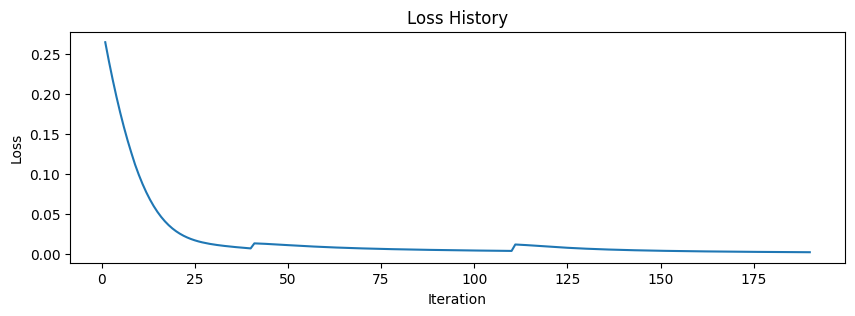

In [11]:
# Multiscale fwi using multi-GPU
loss_multiplier = 1e6
n_shots_per_batch = 24
n_batch = (n_shots + n_shots_per_batch - 1) // n_shots_per_batch

learning_rate = 1e-2

model = Model(v_init_tensor, 1200.0, 4000.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss_history = []

print("Starting FWI...")
for cutoff in [10, 15, 25]:
    print(f"\n--- {cutoff}Hz Band ---")

    if cutoff == 10:
        learning_rate = 5e-3
        optimizer.param_groups[0]['lr'] = learning_rate 
        loss_multiplier = 1e6
        n_epochs = 40
    elif cutoff == 15:
        learning_rate = 1e-3
        optimizer.param_groups[0]['lr'] = learning_rate
        loss_multiplier = 1e5
        n_epochs = 70
    else:
        learning_rate = 1e-3
        optimizer.param_groups[0]['lr'] = learning_rate
        loss_multiplier = 1e4
        n_epochs = 80
    sos = get_filter(cutoff, dt, device)
    
    obs_filt_cpu = apply_filt(torch.from_numpy(observed_data_cpu).to(device), sos).cpu().detach().numpy()
    
    for i in range(n_epochs):
        optimizer.zero_grad()
        epoch_loss = 0.0
        
        for batch in range(n_batch):
            batch_start = batch * n_shots_per_batch
            batch_end = min(batch_start + n_shots_per_batch, n_shots)
            s = slice(batch_start, batch_end)
            
            v = model()
            

            out = scalar(v, (dz, dy, dx), dt, 
                      source_amplitudes=source_amplitudes[s],
                      source_locations=source_locations[s], 
                      receiver_locations=receiver_locations[s],
                      pml_freq=freq, 
                      pml_width=pml_width,
                      storage_mode = "cpu")[-1]
            
            out_filt = apply_filt(taper(out), sos)
            
            obs_filt = torch.from_numpy(obs_filt_cpu[s]).to(device)
            
            loss = torch.nn.MSELoss()(out_filt, obs_filt) * loss_multiplier
            
            # Accumulate gradients
            (loss / n_batch).backward()
            epoch_loss += loss.item()
            
        optimizer.step()
        print(f"Step {i} | Loss: {epoch_loss / n_batch:.6f}")
        loss_history.append(epoch_loss / n_batch)


del out, obs_filt, out_filt, v, s, batch_start, batch_end, loss, epoch_loss, optimizer
torch.cuda.empty_cache()

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(range(1, len(loss_history)+1), loss_history)
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Loss History")
plt.show()


## Results — true, initial, and inverted $v_p$

Side-by-side 3D views of the reference model, the smoothed starting model, and the model after multiscale FWI.

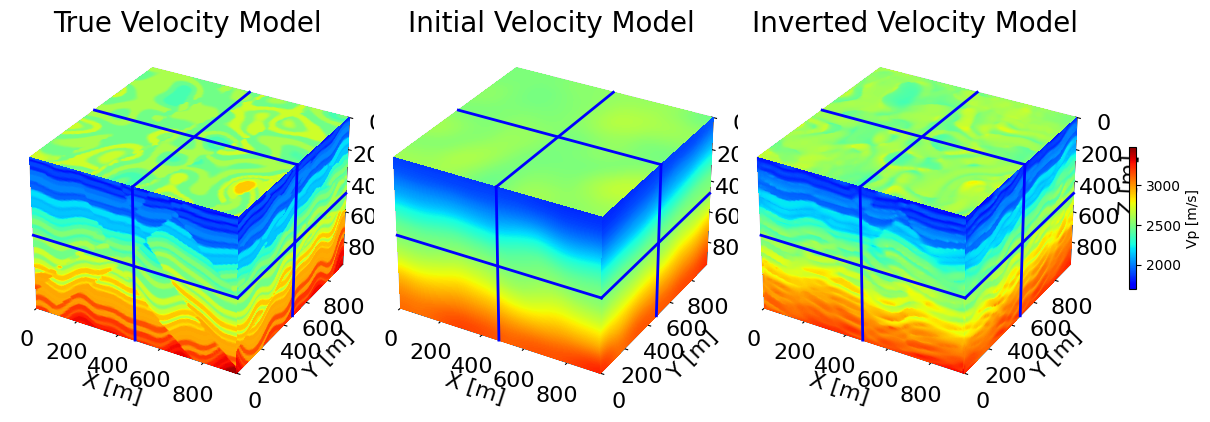

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), subplot_kw = {"projection": "3d"}, constrained_layout=True)
frames = None #[80, 10, 80]
plt.sca(ax[0])
plot3d(
    v_true,
    cmap = "jet",
    vmin = 1500, vmax = 3500,
    ifnewfig=False,
    ifinside=False,
    showf=False,
    close=False,
    frames = frames,
    nlevel=1000,
    dx=10.0, dy=10.0, dz=10.0
)

ax[0].set_title("True Velocity Model", fontsize=20)
ax[0].tick_params(labelsize=16)
ax[0].set_xlabel('X [m]', fontsize=16)
ax[0].set_ylabel('Y [m]', fontsize=16)
# ax[0].set_zlabel('Z [m]', fontsize=16)
ax[0].set_zlabel('')

plt.sca(ax[1])
plot3d(
    v_init,
    cmap = "jet",
    vmin = 1500, vmax = 3500,
    dx=10.0, dy=10.0, dz=10.0,
    ifnewfig=False,
    ifinside=False,
    showf=False,
    close=False,
    frames = frames,
    nlevel=1000,
)
ax[1].set_title("Initial Velocity Model", fontsize=20)
ax[1].tick_params(labelsize=16)
ax[1].set_xlabel('X [m]', fontsize=16)
ax[1].set_ylabel('Y [m]', fontsize=16)
# ax[1].set_zlabel('Z [m]', fontsize=16)
ax[1].set_zlabel('')

with torch.no_grad():
    v_final_cpu = model().cpu().numpy()

plt.sca(ax[2])
plot3d(
    v_final_cpu,
    cmap = "jet",
    vmin = 1500, vmax = 3500,
    dx=10.0, dy=10.0, dz=10.0,
    frames = frames,
    nlevel=1000,
    ifnewfig=False,
    ifinside=False,
    showf=False,
    close=False,
    barlabel="Vp [m/s]",
)
ax[2].set_title("Inverted Velocity Model", fontsize=20)
ax[2].tick_params(labelsize=16)
ax[2].set_xlabel('X [m]', fontsize=16)
ax[2].set_ylabel('Y [m]', fontsize=16)
ax[2].set_zlabel('Z [m]', fontsize=16)


# plt.savefig("model0000-results.png", dpi=300)
plt.show()

### Quantitative misfit vs. truth

Mean absolute error (MAE) and root-mean-square error (RMSE) between $v_{\mathrm{init}}$ / $v_{\mathrm{final}}$ and $v_{\mathrm{true}}$ summarize how much the velocity model improved.

In [13]:
mae_init = np.abs(v_init - v_true).mean()
rmse_init = np.sqrt(np.mean((v_init - v_true)**2))
mae_final = np.abs(v_final_cpu - v_true).mean()
rmse_final = np.sqrt(np.mean((v_final_cpu - v_true)**2))

print(f"MAE Initial: {mae_init:.2f}, RMSE Initial: {rmse_init:.2f}")
print(f"MAE Final: {mae_final:.2f}, RMSE Final: {rmse_final:.2f}")  


MAE Initial: 70.11, RMSE Initial: 84.65
MAE Final: 49.55, RMSE Final: 67.87


In [2]:
arrays_to_save = [v_true, v_init, v_final_cpu]
np.savez("model0000-results.npz", *arrays_to_save)

NameError: name 'v_true' is not defined

## Poor initial model — second FWI experiment

The first run used a **kinematically accurate** starting model: a Gaussian-smoothed version of $v_{\mathrm{true}}$, so large-scale structure and average velocities are already close to the answer.

This section repeats the **same multiscale FWI loop** with a deliberately **poor** starting model:

```python
v_init = np.linspace(1500, 3500, 96).reshape(-1, 1, 1).repeat(96, axis=1).repeat(96, axis=2)
```

That builds a simple **vertical gradient** from 1500 to 3500 m/s with **no lateral structure** and no relation to the true geology. It is smooth and within bounds, but it misrepresents reflectors, faults, and salt bodies.

**Why this matters for FWI**

- FWI is **nonlinear** and can converge to a local minimum if the starting model is too far from the truth.
- Low-frequency data help, but a bad $v_{\mathrm{init}}$ can still leave **artifacts**, **blurred interfaces**, or **wrong amplitudes** in the final model.
- Comparing good vs. poor starts separates **algorithm behavior** from **starting-model quality**.


In [ ]:
v_init = np.linspace(1500, 3500, 96, dtype=np.float32).reshape(-1, 1, 1).repeat(96, axis=1).repeat(96, axis=2)
v_init_tensor = torch.from_numpy(v_init).to(device)

model = Model(v_init_tensor, 1200.0, 4000.0).to(device)

# Multiscale fwi using multi-GPU
loss_multiplier = 1e6
n_shots_per_batch = 24
n_batch = (n_shots + n_shots_per_batch - 1) // n_shots_per_batch

learning_rate = 1e-2

model = Model(v_init_tensor, 1200.0, 4000.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss_history = []

print("Starting FWI...")
for cutoff in [10, 15, 25]:
    print(f"\n--- {cutoff}Hz Band ---")

    if cutoff == 10:
        learning_rate = 5e-3
        optimizer.param_groups[0]['lr'] = learning_rate 
        loss_multiplier = 1e6
        n_epochs = 40
    elif cutoff == 15:
        learning_rate = 1e-3
        optimizer.param_groups[0]['lr'] = learning_rate
        loss_multiplier = 1e5
        n_epochs = 70
    else:
        learning_rate = 1e-3
        optimizer.param_groups[0]['lr'] = learning_rate
        loss_multiplier = 1e4
        n_epochs = 80
    sos = get_filter(cutoff, dt, device)
    
    obs_filt_cpu = apply_filt(torch.from_numpy(observed_data_cpu).to(device), sos).cpu().detach().numpy()
    
    for i in range(n_epochs):
        optimizer.zero_grad()
        epoch_loss = 0.0
        
        for batch in range(n_batch):
            batch_start = batch * n_shots_per_batch
            batch_end = min(batch_start + n_shots_per_batch, n_shots)
            s = slice(batch_start, batch_end)
            
            v = model()
            

            out = scalar(v, (dz, dy, dx), dt, 
                      source_amplitudes=source_amplitudes[s],
                      source_locations=source_locations[s], 
                      receiver_locations=receiver_locations[s],
                      pml_freq=freq, 
                      pml_width=pml_width,
                      storage_mode = "cpu")[-1]
            
            out_filt = apply_filt(taper(out), sos)
            
            obs_filt = torch.from_numpy(obs_filt_cpu[s]).to(device)
            
            loss = torch.nn.MSELoss()(out_filt, obs_filt) * loss_multiplier
            
            # Accumulate gradients
            (loss / n_batch).backward()
            epoch_loss += loss.item()
            
        optimizer.step()
        print(f"Step {i} | Loss: {epoch_loss / n_batch:.6f}")
        loss_history.append(epoch_loss / n_batch)


del out, obs_filt, out_filt, v, s, batch_start, batch_end, loss, epoch_loss, optimizer
torch.cuda.empty_cache()

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(range(1, len(loss_history)+1), loss_history)
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Loss History")
plt.show()


### Comparing good vs. poor starting models

The figure below loads:

- **`model0000-results.npz`** — smoothed, kinematically accurate $v_{\mathrm{init}}$
- **`model0000-results-poor-init.npz`** — vertical-gradient $v_{\mathrm{init}}$

**Rows 1–2:** inversion with the good start (center and edge slices). Panel (f) marks zones with limited illumination where recovery is hardest even with a good initial model.

**Row 3:** source positions (g), poor $v_{\mathrm{init}}$ (h), and the corresponding inverted model (i). Compare panel (c) with (i) to see how starting-model quality affects the final $v_p$.


In [3]:
data1 = np.load("model0000-results.npz")
v_true1 = data1["arr_0"]
v_init1 = data1["arr_1"]
v_final_cpu1 = data1["arr_2"]

data2 = np.load("model0000-results-poor-init.npz")
v_init2 = data2["arr_1"]
v_final_cpu2 = data2["arr_2"]

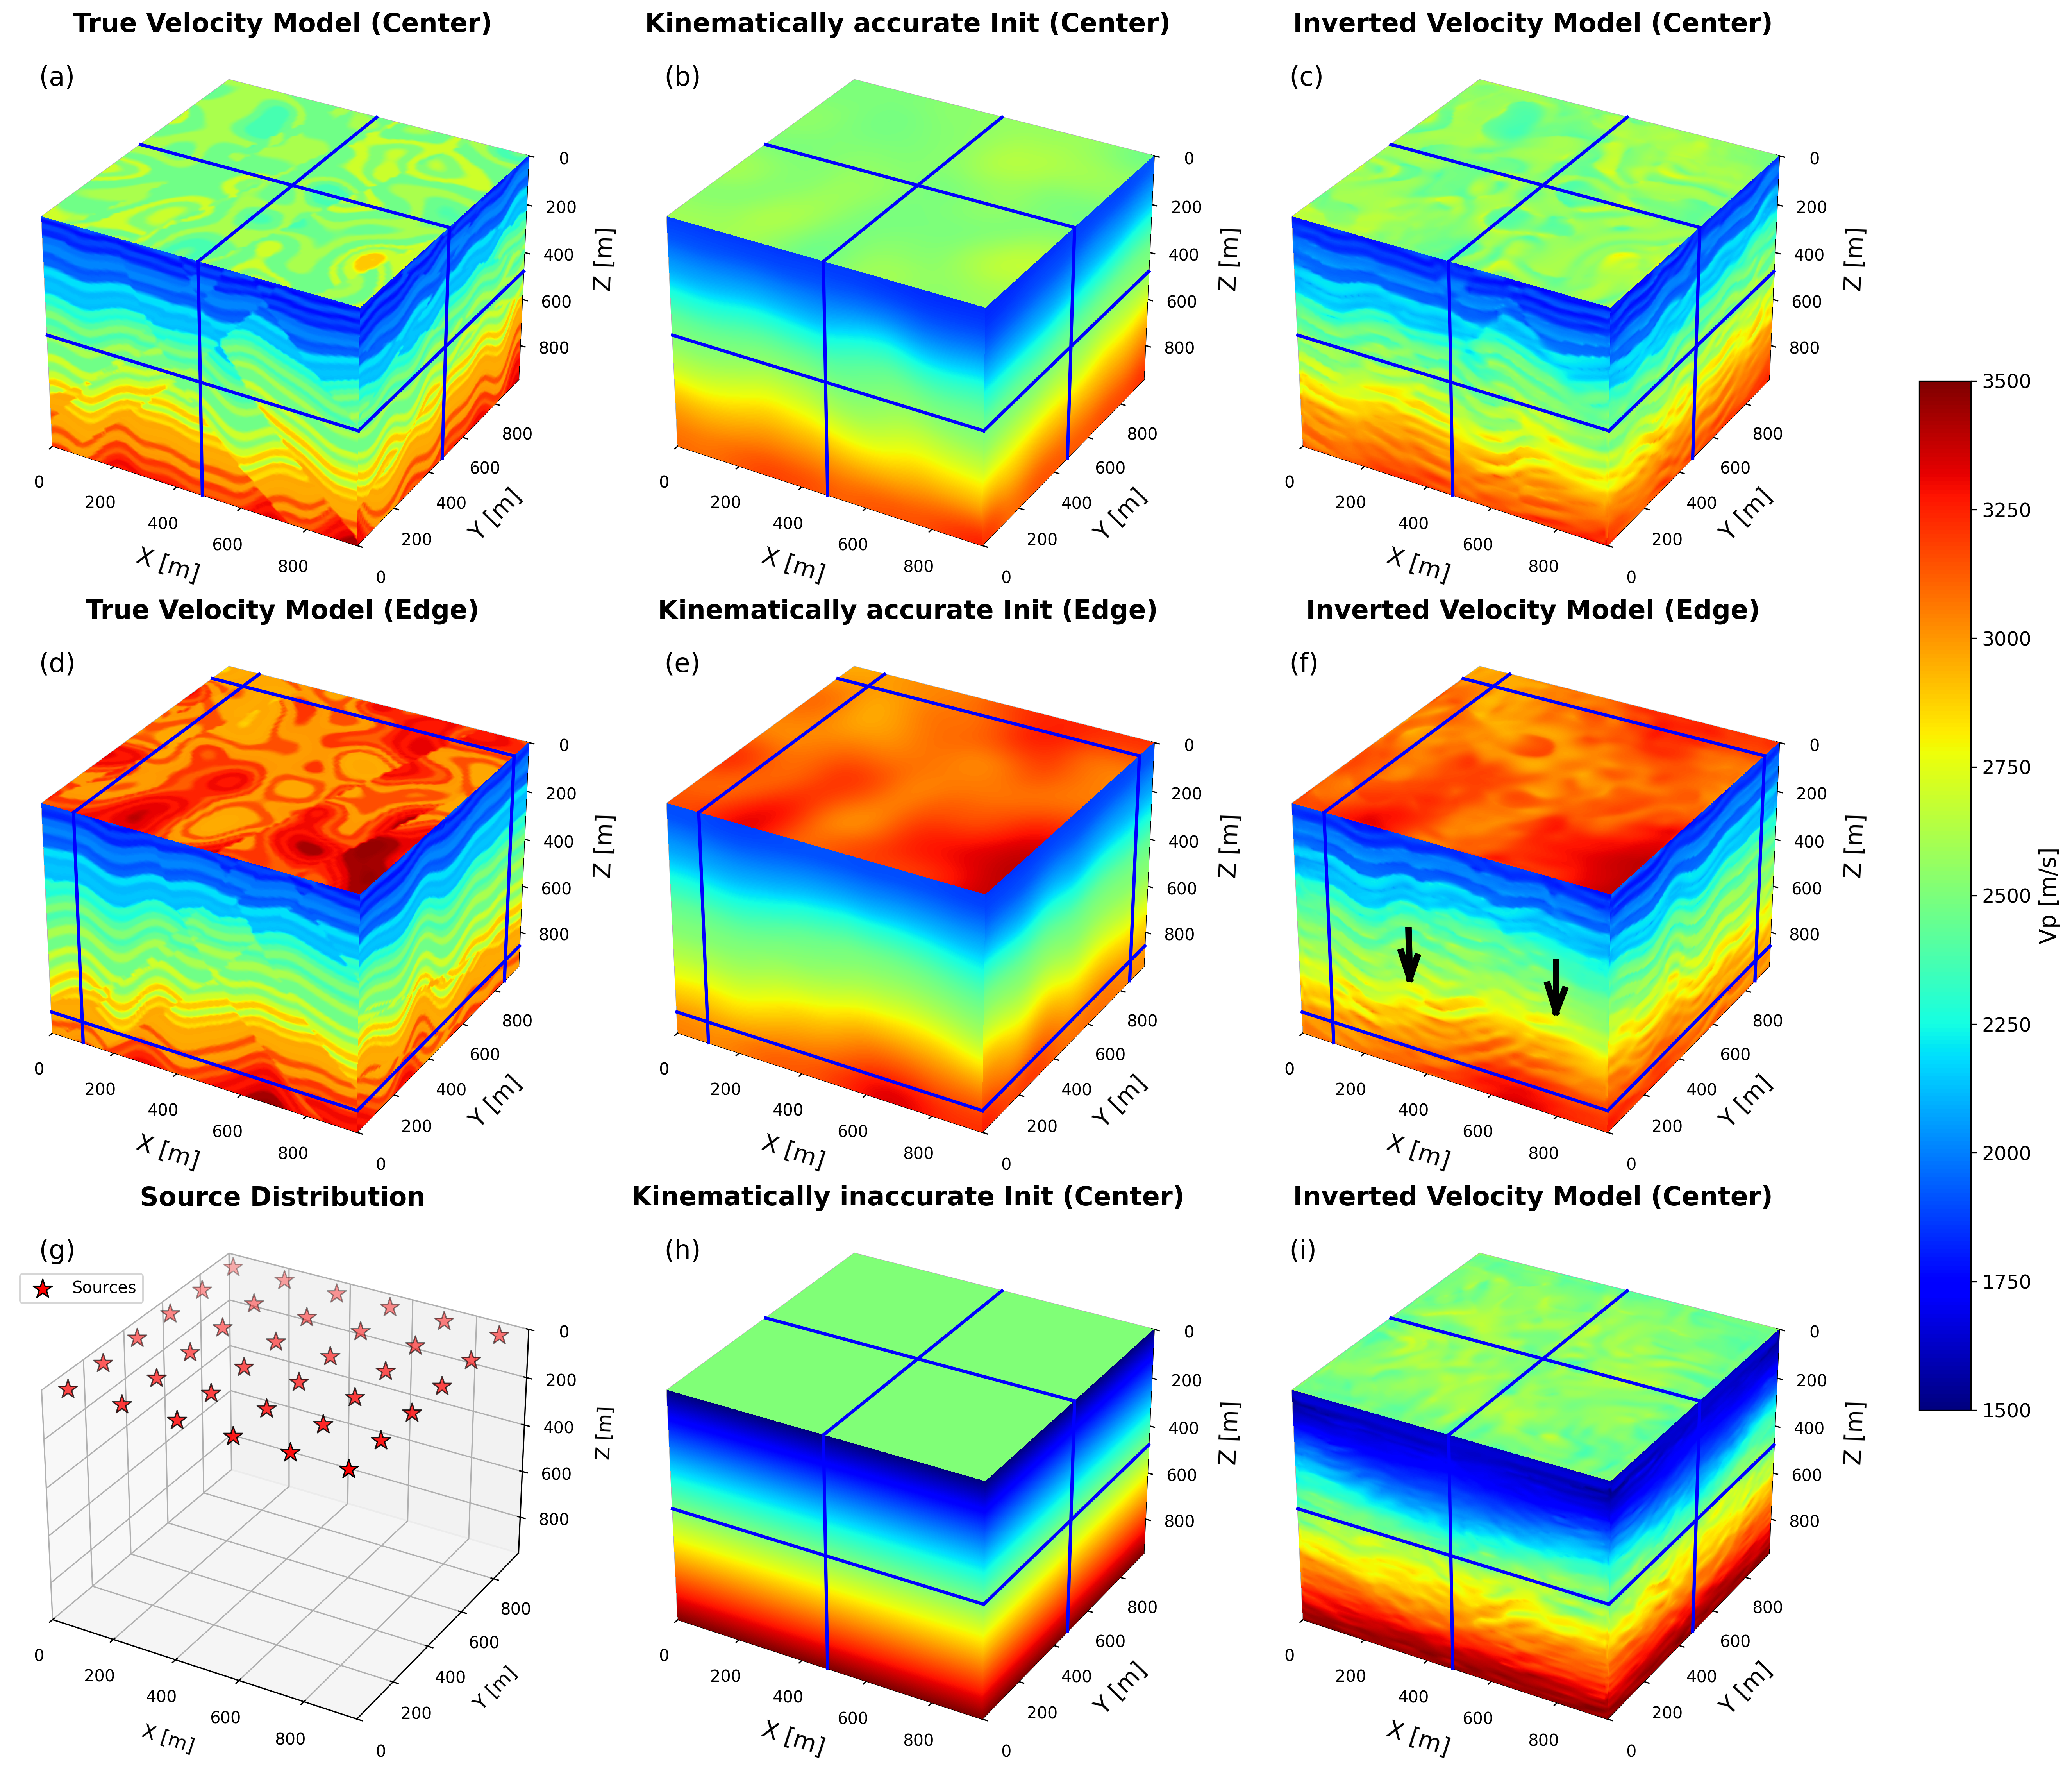

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch

# Load data
data1 = np.load("model0000-results.npz")
v_true1 = data1["arr_0"]
v_init1 = data1["arr_1"]
v_final_cpu1 = data1["arr_2"]

data2 = np.load("model0000-results-poor-init.npz")
v_init2 = data2["arr_1"]
v_final_cpu2 = data2["arr_2"]

# 1. Set global publication-quality typography and resolution
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'figure.dpi': 300
})

# 2. Setup Figure (3 rows, 3 columns)
fig, axes = plt.subplots(
    3, 3, 
    figsize=(18, 15), # Increased height for 3 rows
    subplot_kw={"projection": "3d"}, 
    constrained_layout=True
)

# Define slicing frames
frames_mid = [48, 48, 48]  # Center of the 96x96x96 volume
frames_edge = [86, 10, 86] # Edge of the volume (poor illumination zone)

# Define items for all 9 slots in the 3x3 grid. 
# Format: (volume_data, "Title", 'Panel_Letter', slicing_frames)
plot_items = [
    # ROW 1: Good Init - Middle Slices
    (v_true1, "True Velocity Model (Center)", 'a', frames_mid),
    (v_init1, "Kinematically accurate Init (Center)", 'b', frames_mid),
    (v_final_cpu1, "Inverted Velocity Model (Center)", 'c', frames_mid),
    
    # ROW 2: Good Init - Edge Slices
    (v_true1, "True Velocity Model (Edge)", 'd', frames_edge),
    (v_init1, "Kinematically accurate Init (Edge)", 'e', frames_edge),
    (v_final_cpu1, "Inverted Velocity Model (Edge)", 'f', frames_edge),
    
    # ROW 3: Source Distribution & Poor Init - Middle Slices
    (None, "Source Distribution", 'g', None),  # None triggers the scatter plot
    (v_init2, "Kinematically inaccurate Init (Center)", 'h', frames_mid),
    (v_final_cpu2, "Inverted Velocity Model (Center)", 'i', frames_mid)
]

# 3. Consolidated Plotting Loop
for i, (ax, item) in enumerate(zip(axes.flatten(), plot_items)):
    
    vol, title, letter, panel_frames = item
    
    # ==========================================
    # INTERCEPT FOR SOURCE GEOMETRY PLOT
    # ==========================================
    if vol is None:
        ax.set_title(title, pad=-15)
        
        # Manually set the 3D box limits
        ax.set_xlim([0, 960])
        ax.set_ylim([0, 960])
        ax.set_zlim([960, 0]) # Inverted Z-axis
        
        dx, dy, dz = 10.0, 10.0, 10.0
        
        # Extract coordinates (assuming source_locations is available in your namespace)
        sz_grid = source_locations[:, 0, 0].cpu().numpy()
        sy_grid = source_locations[:, 0, 1].cpu().numpy()
        sx_grid = source_locations[:, 0, 2].cpu().numpy()
        
        sz = sz_grid * dz
        sy = sy_grid * dy
        sx = sx_grid * dx
        
        # Plot the sources as red stars
        ax.scatter(sx, sy, sz, 
                   color='red', 
                   marker='*', 
                   s=150, 
                   edgecolors='black', 
                   linewidths=0.8, 
                   zorder=100, 
                   label='Sources')
        ax.legend(loc='upper left', bbox_to_anchor=(0.0, 0.9), fontsize=10, framealpha=0.8)
        
        # Format the axis
        ax.tick_params(labelsize=10, pad=5)
        ax.set_xlabel('X [m]', labelpad=10, fontweight='normal')
        ax.set_ylabel('Y [m]', labelpad=10, fontweight='normal')
        ax.set_zlabel('Z [m]', labelpad=10, fontweight='normal')
        
        # Add panel letter
        ax.text2D(0.05, 0.95, f'({letter})', transform=ax.transAxes, fontsize=16, va='top', ha='left')
        ax.set_rasterized(True)
        
        continue # Skip the plot3d code below
    # ==========================================
        
    ax.set_title(title, pad=-15)
    plt.sca(ax)

    # Plot using your custom plot3d function with the specific frames for this panel
    plot3d(
        vol,
        cmap="jet",
        vmin=1500, vmax=3500,
        dx=10.0, dy=10.0, dz=10.0,
        ifnewfig=False,
        ifinside=False,
        showf=False,
        close=False,
        frames=panel_frames,
        nlevel=3000
    )

    # ==========================================
    # ADD 3D ARROWS TO SPECIFIC PANEL
    # ==========================================
    if letter == 'f':
        def draw_down_arrow(x, y, z_start, z_end):
            # 1. Draw the main shaft
            ax.plot([x, x], [y, y], [z_start, z_end], color='black', linewidth=4, zorder=1000)
            
            # 2. Draw the arrowhead explicitly using lines
            # dx controls how wide the arrowhead is. dz controls how tall it is.
            dx = 25  
            dz = 100  
            
            # Left wing of the arrowhead
            ax.plot([x, x - dx], [y, y], [z_end, z_end - dz], color='black', linewidth=4, zorder=1000)
            # Right wing of the arrowhead
            ax.plot([x, x + dx], [y, y], [z_end, z_end - dz], color='black', linewidth=4, zorder=1000)

        # Draw the three arrows pointing at the poor illumination zones
        draw_down_arrow(x=300, y=80, z_start=450, z_end=650)
        # draw_down_arrow(x=500, y=80, z_start=400, z_end=700)
        draw_down_arrow(x=750, y=80, z_start=400, z_end=600)
    # ==========================================

    # Professional axis formatting
    ax.tick_params(labelsize=10, pad=5)
    ax.set_xlabel('X [m]', labelpad=10, fontweight='normal')
    ax.set_ylabel('Y [m]', labelpad=10, fontweight='normal')
    ax.set_zlabel('Z [m]', labelpad=10, fontweight='normal')

    # Anchor the panel labels
    ax.text2D(
        0.05, 0.95, 
        f'({letter})', 
        transform=ax.transAxes, 
        fontsize=16, 
        fontweight="normal",
        va='top', 
        ha='left',
        zorder=10
    )
    ax.set_rasterized(True)

# 4. Create a single, unified colorbar for the entire figure
norm = mcolors.Normalize(vmin=1500, vmax=3500)
sm = cm.ScalarMappable(cmap="jet", norm=norm)
sm.set_array([])

# Attach the colorbar to the right side of the figure
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.6, pad=0.05)
cbar.set_label("Vp [m/s]", fontsize=14, fontweight='normal')

# plt.savefig("model0000-fwi-v2.pdf", dpi=300, bbox_inches='tight')
plt.show()